**Introduction** <br>
The aim of this project is to find the best suitable Region to build a new oil well for the OilyGiant mining company. The project includes several parts; collecting oil well parameters, building a predictive model, selecting the wells with the highest estimated values, and selecting the region with the highest total profit for the selected oil wells. 


# Data Preparation

In [ ]:
# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error

In [ ]:
#pull in data
g1 = pd.read_csv('geo_data_0.csv')
g2 = pd.read_csv('geo_data_1.csv')
g3 = pd.read_csv('geo_data_2.csv')

In [ ]:
display(g1)

In [ ]:
display(g2)

In [ ]:
display(g3)

In [ ]:
#Check each dataset for duplicates, datatypes, and missing values.
g1.info()
print("\n")
g2.info()
print("\n")
g3.info()

In [ ]:
g1.duplicated().sum()

In [ ]:
g2.duplicated().sum()

In [ ]:
g3.duplicated().sum()

<div class="alert alert-success">
<b>Reviewer's comment V1</b>

Correct

</div>

The  data sets consist of 5 columns and 100,000 rows of data. The Id column datatype is considered object since it is a mixture of letters (uppercase and lower case) along with numbers intertwined.  The other 4 columns datatype are float64 which allows a broader range of numbers.
No Duplicates, no missing val.

# Visuals of Data

In [ ]:
# Calculate the frequencies and bin edges for the bar chart
counts, bin_edges = np.histogram(g1['product'], bins=50)

# Create the bar chart with white grid
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), color='lightblue', edgecolor='maroon', align='edge')

plt.title('Distribution of Reserves in Geo_0')
plt.xlabel('Volume of Reserves (Thousand Barrels)')
plt.ylabel('Frequency')
plt.grid(True, color='grey')
plt.gca().set_facecolor('lightyellow')

plt.show()

**Quick Sum**
Histogram showing the distribution of reserves in Geo_0.
The x-axis represents the volume of reserves (in thousand barrels), and the y-axis represents the frequency (the number of occurrences).
Bars are colored sky blue with a red edge.
The distribution shows a roughly symmetric pattern with peaks around 50–125 thousand barrels.

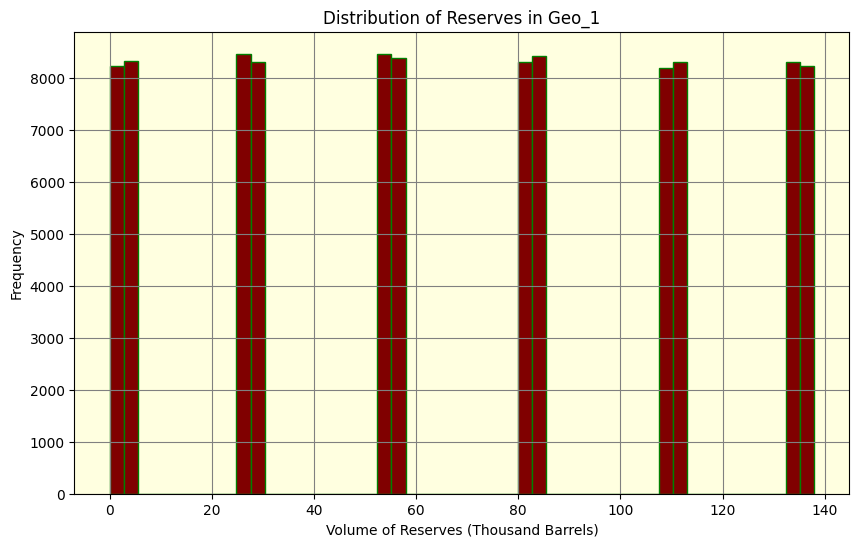

In [11]:
# Calculate the frequencies and bin edges for the bar chart
counts, bin_edges = np.histogram(g2['product'], bins=50)

# Create the bar chart with white grid
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), color='maroon', edgecolor='green', align='edge')

plt.title('Distribution of Reserves in Geo_1')
plt.xlabel('Volume of Reserves (Thousand Barrels)')
plt.ylabel('Frequency')
plt.grid(True, color='grey')
plt.gca().set_facecolor('lightyellow')
plt.show()

**Quick Summary**
Histogram of the reserves in Geo_1.
The x-axis shows the volume of reserves (up to around 140 thousand barrels), while the y-axis displays the frequency.
Bars are colored maroon with a black edge.
The graph shows a very consistent distribution, with most frequencies peaking at around 8,000, with regular gaps between peaks.

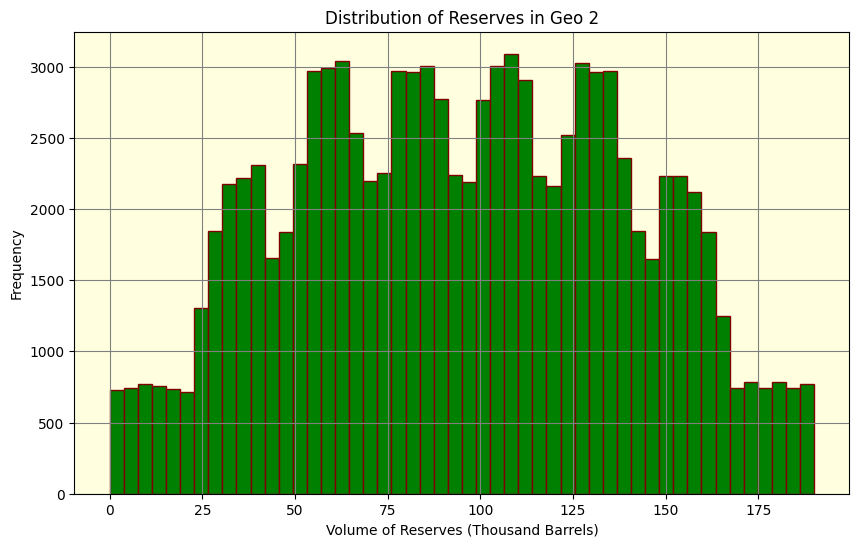

In [12]:
# Calculate the frequencies and bin edges for the bar chart
counts, bin_edges = np.histogram(g3['product'], bins=50)

# Create the bar chart with white grid
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), color='green', edgecolor='maroon', align='edge')

plt.title('Distribution of Reserves in Geo 2')
plt.xlabel('Volume of Reserves (Thousand Barrels)')
plt.ylabel('Frequency')
plt.grid(True, color='grey')
plt.gca().set_facecolor('lightyellow')

plt.show()

**Quick Sum**
Histogram of the reserves in Geo_2.
The x-axis represents the volume of reserves, and the y-axis is the frequency.
Bars are colored green with a red edge.
The distribution has a similar pattern to the first graph (Geo_0), with multiple peaks between 50 and 125 thousand barrels.

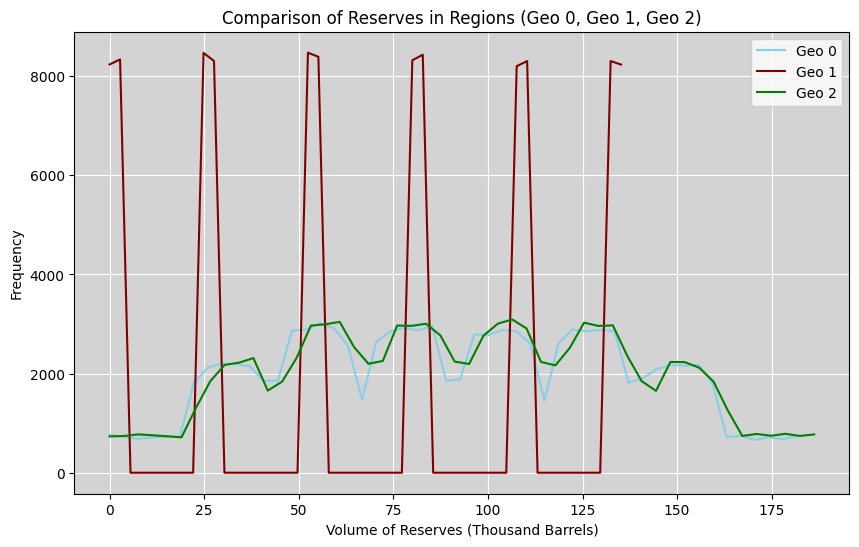

In [13]:

plt.figure(figsize=(10, 6))

# Plotting g1 as a line graph
counts_g1, bin_edges_g1 = np.histogram(g1['product'], bins=50)
plt.plot(bin_edges_g1[:-1], counts_g1, label='Geo 0', color='skyblue')

# Plotting g2 as a line graph
counts_g2, bin_edges_g2 = np.histogram(g2['product'], bins=50)
plt.plot(bin_edges_g2[:-1], counts_g2, label='Geo 1', color='maroon')

# Plotting g3 as a line graph
counts_g3, bin_edges_g3 = np.histogram(g3['product'], bins=50)
plt.plot(bin_edges_g3[:-1], counts_g3, label='Geo 2', color='green')

# Titles and labels
plt.title('Comparison of Reserves in Regions (Geo 0, Geo 1, Geo 2)')
plt.xlabel('Volume of Reserves (Thousand Barrels)')
plt.ylabel('Frequency')
plt.grid(True, color='white')
plt.gca().set_facecolor('lightgray')  
plt.legend()

plt.show()

**Quick Sum**
Line graph comparing the reserves across Geo_0, Geo_1, and Geo_2.
The x-axis is the volume of reserves, and the y-axis is the frequency.
Geo_0 is represented in light blue, Geo_1 in maroon, and Geo_2 in green.
The graph shows how the distributions differ between the three regions. Geo_1 has distinct high peaks, while Geo_0 and Geo_2 have more fluctuating trends.

# Train and Test Model

In [14]:
#Create a function to  split dataset
def train_test_model(data):
    # Split data into features (X) and target (y)
    features = data.drop(['id', 'product'], axis=1)
    target = data['product']
    
    # Split data into training and validation sets
    features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size = 0.25, random_state=42)
    
    # Train the model
    model = LinearRegression()
    model.fit(features_train, target_train)
    
    # Make predictions on validation set
    target_pred = model.predict(features_valid)
    
    # Calculate the RMSE
    rmse = mean_squared_error(target_valid, target_pred, squared=False)
    
    # Print average volume of predicted reserves and model RMSE
    print("Average Volume of Predicted Reserves:", target_pred.mean())
    print("Model RMSE:", rmse)
    
    return model, target_pred, target_valid

In [15]:
# Train and test model for each region

print("Region Geo_0 :")
model_g0, predictions_g0, true_values_g0 = train_test_model(g1)

Region Geo_0 :
Average Volume of Predicted Reserves: 92.3987999065777
Model RMSE: 37.756600350261685


In [16]:
print("Region Geo_1 :")
model_g1, predictions_g1, true_values_g1 = train_test_model(g2)

Region Geo_1 :
Average Volume of Predicted Reserves: 68.71287803913762
Model RMSE: 0.890280100102884


In [17]:
print("Region Geo_2:")
model_g2, predictions_g2, true_values_g2 = train_test_model(g3)

Region Geo_2:
Average Volume of Predicted Reserves: 94.77102387765939
Model RMSE: 40.14587231134218


**QUICK SUMMARY:: ** 

| <u>**Region**<u> | <u>**Summary**<u> |
| ----------- | :----------- |
| **Geo_0** |Average Volume of Predicted Reserves: 92.3987993065777. <br> Model RMSE: 37.75606035206185.<br>The model has a moderately high RMSE, indicating some error in predictions for reserves in Geo_0.    |
| **Geo_1** | Average Volume of Predicted Reserves: 68.71287809313762.<br>Model RMSE: 0.89028100102384.<br>RMSE here is very low, suggesting that the model is performing well in predicting reserves for Geo_1 with minimal error. |
|**Geo_2** | Average Volume of Predicted Reserves: 94.77102387765399.<br>Model RMSE: 40.14587231134218.<br> The model has a relatively high RMSE, showing that predictions for Geo_2 have a significant margin of error.|

    
<br> The model performs best in Geo_1, as indicated by the very low RMSE (closer to zero means better performance).
The performance in Geo_0 and Geo_2 shows higher RMSE values, indicating larger prediction errors for reserves in these regions.

# Profit Calculation Preparation

<u>**Conditions**<u>
    
<br>When exploring the region, a study of 500 points is carried with picking the best 200 points for the profit calculation.
	The budget for development of 200 oil wells is 100 USD million.
    <br>One barrel of raw materials brings 4.5 USD of revenue The revenue from one unit of product is 4,500 dollars (volume of reserves is in thousand barrels).
    <br>After the risk evaluation, keep only the regions with the risk of losses lower than 2.5%. From the ones that fit the criteria, the region with the highest average profit should be selected.


###  3.1. Store all key Values for calculations in seperate variables.

In [18]:
# Store Key Values all in USD
budget = 100000000
revenue_per_barrel = 4.5
total_wells = 200

cost_per_well = budget / total_wells # = $500,000 per well

###  3.2. Calculate the volume of reserves sufficient for developing a new well without losses. 

In [19]:
# Calculate average volume of reserves in each region
avg_volume_region_0 = g1['product'].mean()
avg_volume_region_1 = g2['product'].mean()
avg_volume_region_2 = g3['product'].mean()

In [20]:
break_even_volume = cost_per_well / revenue_per_barrel 
print(f"Break-even volume of reserves per well (barrels): {break_even_volume:.3f}")

# The volume of "reserves" is given in thousand barrels, convert to thousand barrels:
break_even = break_even_volume / 1000
print(f"Break even in thousand barrels: {break_even}")

Break-even volume of reserves per well (barrels): 111111.111
Break even in thousand barrels: 111.11111111111111


 #### 3.2. Compare the obtained value with the average volume of reserves in each region.

In [21]:
print("Average volume of reserves in each region (thousand barrels):")
print(f"Region Geo_0: {avg_volume_region_0:.3f}")
print(f"Region Geo_1: {avg_volume_region_1:.3f}")
print(f"Region Geo_2: {avg_volume_region_2:.3f}")

Average volume of reserves in each region (thousand barrels):
Region Geo_0: 92.500
Region Geo_1: 68.825
Region Geo_2: 95.000


### 3.3 Provide findings about the preparation for profit calculations

| **Header**                                    | **Details**                                                                                                     |
|-----------------------------------------------|:-----------------------------------------------------------------------------------------------------------------|
| **Key Values for Calculations**                   | - Budget: \\$100,000,000 <br> - Revenue per barrel:\\$4.5 <br> - Total wells: 200 <br> - Cost per well: \\$500000
| Calculating Break-even Volume                 | The break-even volume of reserves per well is calculated using the formula: <br> break_even_volume = cost_per_well / revenue_per_barrel =  111,111.11 barrels <br> Converted to thousand barrels: 111.111   |
| Average Volume of Reserves in Each Region     | - Region Geo_0: 92.5 thousand barrels <br> - Region Geo_1: 68.8 thousand barrels <br> - Region Geo_2: 95 thousand barrels   |


**Comparison:** <br>
The break-even volume (111.1 thousand barrels) is higher than the average volume of reserves in all three regions, meaning none of the regions have enough reserves to cover the cost of a new well without losses based on these calculations. <br>
**Insights:** <br>
Based on the comparison, all regions fall short of the break-even point, with Geo_1 having the least amount of reserves. Profitability would be unlikely without adjustments to costs or revenue per barrel.

# Write a function to calculate profit from a set of selected oil wells and model prediction

In [22]:
def calculate_profit(predictions, true_values, budget=100000000, cost_per_well=500000, revenue_per_barrel=4.5, top_x_wells=200):
    # Select the top x wells with the highest predicted values
    top_wells_indices = predictions.argsort()[-top_x_wells:][::-1]
    selected_true_values = true_values[top_wells_indices]

    # Calculate the total volume of reserves for the selected wells
    total_volume = selected_true_values.sum()

    # Calculate the profit
    total_revenue = total_volume * revenue_per_barrel * 1000  # Convert thousand barrels to barrels
    total_cost = top_x_wells * cost_per_well
    profit = total_revenue - total_cost

    return profit, total_volume

In [23]:
# Convert pandas Series to numpy arrays
predictions_g0 = np.array(predictions_g0)
true_values_g0 = np.array(true_values_g0)

predictions_g1 = np.array(predictions_g1)
true_values_g1 = np.array(true_values_g1)

predictions_g2 = np.array(predictions_g2)
true_values_g2 = np.array(true_values_g2)

# Profit Calculations

In [24]:
# Calculate profit for each region
profit_g0, total_volume_g0 = calculate_profit(predictions_g0, true_values_g0)
profit_g1, total_volume_g1 = calculate_profit(predictions_g1, true_values_g1)
profit_g2, total_volume_g2 = calculate_profit(predictions_g2, true_values_g2)

# Print findings
print(f"Region Geo_0: Total volume of reserves: {total_volume_g0:.2f} thousand barrels, Profit: ${profit_g0:.2f}")
print(f"Region Geo_1: Total volume of reserves: {total_volume_g1:.2f} thousand barrels, Profit: ${profit_g1:.2f}")
print(f"Region Geo_2: Total volume of reserves: {total_volume_g2:.2f} thousand barrels, Profit: ${profit_g2:.2f}")

Region Geo_0: Total volume of reserves: 29686.98 thousand barrels, Profit: $33591411.14
Region Geo_1: Total volume of reserves: 27589.08 thousand barrels, Profit: $24150866.97
Region Geo_2: Total volume of reserves: 27996.83 thousand barrels, Profit: $25985717.59


In [25]:
# Determine the best region
profits = [profit_g0, profit_g1, profit_g2]
best_region = np.argmax(profits)
print(f"Best region for oil wells development is Region {best_region} with a profit of ${profits[best_region]:.2f}")

Best region for oil wells development is Region 0 with a profit of $33591411.14


# Calculate Risks & Profit Per Region:

In [26]:
def calculate_risks_and_profit(profit_samples):
    # Calculate average profit
    avg_profit = np.mean(profit_samples)

    # Calculate 95% confidence interval
    confidence_interval = np.percentile(profit_samples, [2.5, 97.5])

    # Calculate risk of losses
    risk_of_losses = np.mean(profit_samples < 0) * 100

    return avg_profit, confidence_interval, risk_of_losses

In [27]:
# Function to perform bootstrapping and calculate profit samples
def bootstrap_profit(predictions, true_values, budget=1000000000, cost_per_well=500000, revenue_per_barrel=4.5, top_x_wells=200, num_samples=1000, sample_size=500):
    # Initialize list to store profit samples
    profit_samples = []

    # Set random state for reproducibility
    np.random.seed(42)

    # Perform bootstrapping
    for i in range(num_samples):
        # Sample with replacement from predictions and true values
        sampled_predictions, sampled_true_values = resample(predictions, true_values, n_samples=sample_size)

        # Calculate profit for sampled data
        profit, i = calculate_profit(sampled_predictions, sampled_true_values)
        
        # Append profit to samples list
        profit_samples.append(profit)

    return np.array(profit_samples)

In [28]:
# Calculate bootstrap profit for each region
profit_samples_region_g0 = bootstrap_profit(predictions_g0, true_values_g0)
profit_samples_region_g1 = bootstrap_profit(predictions_g1, true_values_g1)
profit_samples_region_g2 = bootstrap_profit(predictions_g2, true_values_g2)

In [29]:
# Calculate risks and profit for each region
avg_profit_g0, confidence_interval_g0, risk_of_losses_g0 = calculate_risks_and_profit(profit_samples_region_g0)
avg_profit_g1, confidence_interval_g1, risk_of_losses_g1 = calculate_risks_and_profit(profit_samples_region_g1)
avg_profit_g2, confidence_interval_g2, risk_of_losses_g2 = calculate_risks_and_profit(profit_samples_region_g2)

In [30]:
# Print findings for each region
print("Region Geo_0:")
print("Average Profit:", avg_profit_g0)
print("95% Confidence Interval:", confidence_interval_g0)
print("Risk of Losses:", risk_of_losses_g0, "%")

Region Geo_0:
Average Profit: 3995754.7805422964
95% Confidence Interval: [-1104678.95331971  8974603.27717881]
Risk of Losses: 6.0 %


In [31]:
# Print findings for each region
print("Region Geo_1:")
print("Average Profit:", avg_profit_g1)
print("95% Confidence Interval:", confidence_interval_g1)
print("Risk of Losses:", risk_of_losses_g1, "%")

Region Geo_1:
Average Profit: 4520488.909064583
95% Confidence Interval: [ 616844.79654225 8453401.77507385]
Risk of Losses: 1.5 %


In [32]:

# Print findings for each region
print("Region Geo_2:")
print("Average Profit:", avg_profit_g2)
print("95% Confidence Interval:", confidence_interval_g2)
print("Risk of Losses:", risk_of_losses_g2, "%")

Region Geo_2:
Average Profit: 3750099.0291532897
95% Confidence Interval: [-1447667.27304894  8883904.03534222]
Risk of Losses: 8.0 %


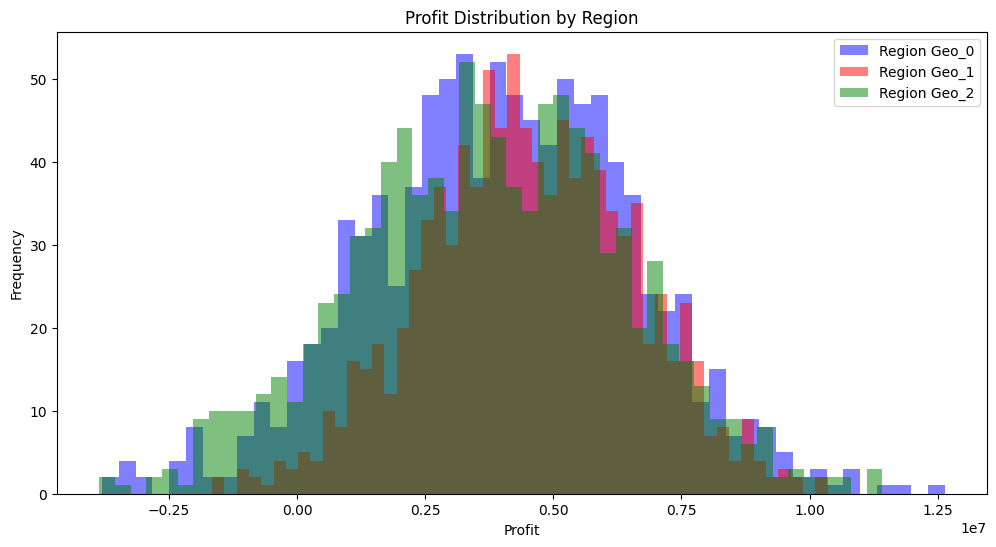

In [33]:
plt.figure(figsize=(12, 6))

# Plot histograms for each region
plt.hist(profit_samples_region_g0, bins=50, color='blue', alpha=0.5, label='Region Geo_0')
plt.hist(profit_samples_region_g1, bins=50, color='red', alpha=0.5, label='Region Geo_1')
plt.hist(profit_samples_region_g2, bins=50, color='green', alpha=0.5, label='Region Geo_2')

# Adding titles and labels
plt.title('Profit Distribution by Region')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.legend()

# Show the plot
plt.show()

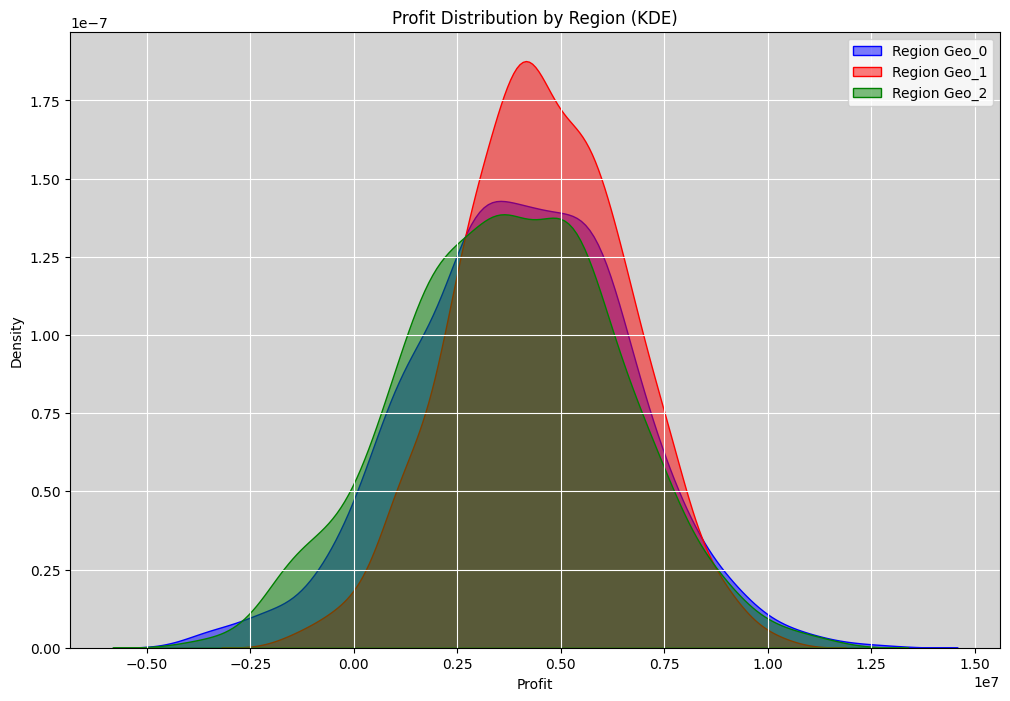

In [34]:

plt.figure(figsize=(12, 8))

# Plotting KDE for each region
sns.kdeplot(profit_samples_region_g0, color='blue', label='Region Geo_0', fill=True, alpha=0.5)
sns.kdeplot(profit_samples_region_g1, color='red', label='Region Geo_1', fill=True, alpha=0.5)
sns.kdeplot(profit_samples_region_g2, color='green', label='Region Geo_2', fill=True, alpha=0.5)

# Adding titles and labels
plt.title('Profit Distribution by Region (KDE)')
plt.xlabel('Profit')
plt.ylabel('Density')

# Adding grid and legend
plt.grid(True, color='white')
plt.gca().set_facecolor('lightgray')  
plt.legend()

plt.show()

**Quick summary**

Conclusion <br>
=====
 Graph Analysis: <br>
----
    Region Geo_0:

        -Distribution: Multimodal, with several distinct peaks.
        -Highest Peak: Between 2,500 and 3,000 thousand barrels.
        -Interpretation: Suggests a range of reserve sizes, indicating multiple clusters of reserves.

    Region Geo_1: 
    
        -Distribution: Bimodal.
        -Highest Peaks: Around 8,000 and 8,500 thousand barrels.
        -Interpretation: Reserves are concentrated around these two levels, indicating a clear divide in sizes.

    Region Geo_2:

        -Distribution: Multimodal, with several peaks and troughs.
        -Highest Peak: Around 3,000 thousand barrels.
        -Interpretation: Reflects a diverse range of reserve sizes, hinting at a complex distribution pattern.

RMSE Analysis:
------

    Region Geo_0: 

        -RMSE: 37.76 
        -Average Predicted Reserve Volume: 92.40 thousand barrels
        -Interpretation: Higher RMSE suggests less accurate predictions,
                    but the predicted reserve volumes are relatively high.  
        
     Region Geo_1: 

        -RMSE: 0.89
        -Average Predicted Reserve Volume: 68.71 thousand barrels
        -Interpretation: The lowest RMSE indicates the most accurate predictions,
                     though this region has the smallest predicted reserve volume. 

     Region Geo_2:

        -RMSE: 40.15
        -Average Predicted Reserve Volume: 94.77 thousand barrels
        -Interpretation: The highest RMSE reflects the least accurate predictions,
                           though it has a relatively high predicted reserve volume.
                           
                           
**Bootstrapping Findings:**
======================

Profit Distribution Analysis:
---------

Region Geo_0 shows a skewed profit distribution with fluctuations and a higher risk of loss, while Region Geo_1 is more uniform and stable. Region Geo_2 has a diverse range of profits but carries a higher risk of loss. Region Geo_1 stands out as the most stable and profitable option, while Regions Geo_0 and Geo_2 show wider distributions and greater risk.

      Region Geo_0:

        -Average Profit: $3,995,754.78
        -95% Confidence Interval: [-$1,104,678.95, $8,974,603.28]
        -Risk of Losses: 6.0%
        
      Region Geo_1:

        -Average Profit: $4,520,488.91
        -95% Confidence Interval: [$616,844.80, $8,453,401.78]
        -Risk of Losses: 1.5%
        
      Region Geo_2:

        -Average Profit: $3,750,099.03
        -95% Confidence Interval: [-$1,447,667.27, $8,883,904.04]
        -Risk of Losses: 8.0%
        
Summary and Recommendations:
------------------------------

        Region Geo_0:
            Region Geo_0 offers high potential profits but with significant variability and moderate risk of losses.
            Its wide confidence interval and moderate risk make it a less reliable option.

        Region Geo1:
            Region Geo_1 has the highest average profit, a narrower confidence interval, and the lowest risk of losses,
            making it the most attractive and reliable option, despite its lower reserve volume.

        Region Geo_2:
            Region Geo_2 shows moderate profits with the highest variability and risk of losses, 
            coupled with the least accurate predictions, making it the least favorable option.

Recommendation:
---------------
Develop oil wells in Region Geo_1 due to its combination of high average profit, low risk, and strong prediction accuracy. While Region Geo_0 offers higher potential profits, the increased variability and risk make Region Geo_1 a more balanced and safer option for maximizing profitability while managing risk effectively.